# Twitter Sentiment Analysis

This notebook loads a locally stored Sentiment140 CSV or ZIP file, preprocesses tweets using tokenization, stop-word removal, and lemmatization, converts text to TF-IDF features, trains multiple classifiers, evaluates them, predicts new tweets, and saves the trained artifacts locally.

## 1. Install dependencies

Run the next cell once. If the packages are already installed, you may skip it. Restart the notebook kernel after installation if imports fail.

In [15]:
# Run once in your local Jupyter environment
%pip install -q pandas numpy scikit-learn nltk tqdm joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Configure local paths and runtime settings

Update `DATASET_PATH` to point to the dataset on your computer. Both CSV and ZIP files are supported when pandas can infer the compression format.

For an initial test, set `SAMPLE_SIZE` to a smaller value such as `100000`. Set it to `None` to use all available tweets.

In [16]:
from pathlib import Path

# Examples:
# Windows: Path(r"C:\Users\YourName\Downloads\training.1600000.processed.noemoticon.csv")
# macOS/Linux: Path("/Users/yourname/Downloads/training.1600000.processed.noemoticon.csv")

DATASET_PATH = Path(r"C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\training.1600000.processed.noemoticon.csv")
OUTPUT_DIR = Path("sentiment_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use None for the full 1.6M-row dataset.
# Use a smaller number while testing the notebook locally.
SAMPLE_SIZE = None

TEST_SIZE = 0.20
RANDOM_STATE = 42
MAX_TFIDF_FEATURES = 100_000

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH.resolve()}\n"
        "Update DATASET_PATH in this cell before continuing."
    )

print("Dataset:", DATASET_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Dataset: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\training.1600000.processed.noemoticon.csv
Output folder: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\sentiment_model_outputs


## 3. Import libraries and download required NLTK resources

In [17]:
import re
import string
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
tqdm.pandas()

for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 4. Load the local Sentiment140 dataset

In [18]:
# Sentiment140 expected columns:
# 0 polarity, 1 tweet ID, 2 date, 3 query, 4 user, 5 text

read_options = {
    "encoding": "latin-1",
    "header": None,
    "compression": "infer",
    "usecols": [0, 5],
    "names": ["polarity", "text"],
}

# nrows avoids loading all 1.6M rows when testing locally.
if SAMPLE_SIZE is not None:
    read_options["nrows"] = SAMPLE_SIZE

df = pd.read_csv(DATASET_PATH, **read_options)

df = df[df["polarity"].isin([0, 4])].copy()
df["polarity"] = df["polarity"].map({0: 0, 4: 1}).astype("int8")
df["text"] = df["text"].fillna("").astype(str)

print("Dataset shape:", df.shape)
print("Memory usage in MB:", round(df.memory_usage(deep=True).sum() / 1024**2, 2))
print("\nClass distribution:")
print(df["polarity"].value_counts().rename(index={0: "Negative", 1: "Positive"}))
df.head()

Dataset shape: (1600000, 2)
Memory usage in MB: 189.57

Class distribution:
polarity
Negative    800000
Positive    800000
Name: count, dtype: int64


,polarity,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


## 5. Define Twitter text preprocessing functions

In [19]:
# Initialize NLP components once, rather than once per tweet
tweet_tokenizer = TweetTokenizer(
    preserve_case=False,
    reduce_len=True,
    strip_handles=False
)

lemmatizer = WordNetLemmatizer()

STOP_WORDS = set(stopwords.words("english"))

# Preserve negation because words such as "not" and "no" affect sentiment
STOP_WORDS -= {"no", "nor", "not"}

PUNCTUATION = set(string.punctuation)


def normalize_social_text(text):
    """Remove or normalize common Twitter-specific text patterns."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # URLs
    text = re.sub(r"@\w+", " ", text)                    # user mentions
    text = re.sub(r"#(\w+)", r"\1", text)               # keep hashtag word
    text = re.sub(r"&amp;", " and ", text)                # HTML entity
    text = re.sub(r"\d+", " ", text)                     # numbers
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)         # repeated characters
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_text(text):
    """Tokenize a tweet with NLTK's Twitter-aware tokenizer."""
    return tweet_tokenizer.tokenize(text)


def remove_stop_words(tokens):
    """Remove English stop words, punctuation, and non-alphabetic tokens."""
    return [
        token
        for token in tokens
        if token not in STOP_WORDS
        and token not in PUNCTUATION
        and token.isalpha()
        and len(token) > 1
    ]


def lemmatize_tokens(tokens):
    """Reduce tokens to their base dictionary form."""
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_text(text):
    """Apply cleaning, tokenization, stop-word removal, and lemmatization."""
    normalized_text = normalize_social_text(text)
    tokens = tokenize_text(normalized_text)
    filtered_tokens = remove_stop_words(tokens)
    lemmas = lemmatize_tokens(filtered_tokens)
    return " ".join(lemmas)


# Demonstrate every preprocessing stage
example_tweet = "@OpenAI I am NOT loving these delays!!! Visit https://example.com #Frustrated"
normalized = normalize_social_text(example_tweet)
tokens = tokenize_text(normalized)
filtered = remove_stop_words(tokens)
lemmas = lemmatize_tokens(filtered)

print("Original:        ", example_tweet)
print("Normalized:      ", normalized)
print("Tokenized:       ", tokens)
print("Stop words out:  ", filtered)
print("Lemmatized:      ", lemmas)
print("Final text:      ", preprocess_text(example_tweet))

Original:         @OpenAI I am NOT loving these delays!!! Visit https://example.com #Frustrated
Normalized:       i am not loving these delays!! visit frustrated
Tokenized:        ['i', 'am', 'not', 'loving', 'these', 'delays', '!', '!', 'visit', 'frustrated']
Stop words out:   ['not', 'loving', 'delays', 'visit', 'frustrated']
Lemmatized:       ['not', 'loving', 'delay', 'visit', 'frustrated']
Final text:       not loving delay visit frustrated


## 6. Preprocess tweets

This can take several minutes on the complete 1.6M-row dataset, depending on the processor and available memory.

In [20]:
df["clean_text"] = df["text"].apply(preprocess_text)

df = df[
    df["clean_text"].str.len() > 0
].reset_index(drop=True)

## 7. Split the dataset

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["polarity"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["polarity"],
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1273357
Testing rows: 318340


## 8. Create TF-IDF features

In [22]:
vectorizer = TfidfVectorizer(
    max_features=MAX_TFIDF_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Training sparse matrix size in MB:", round(
    (X_train_tfidf.data.nbytes + X_train_tfidf.indices.nbytes + X_train_tfidf.indptr.nbytes) / 1024**2, 2
))

Training TF-IDF shape: (1273357, 100000)
Testing TF-IDF shape: (318340, 100000)
Training sparse matrix size in MB: 90.31


## 9. Train sentiment classification models

In [23]:
# Train three classification models
models = {
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=500,
        solver="liblinear",
        random_state=RANDOM_STATE
    )
}

predictions = {}
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    results.append({"Model": model_name, "Accuracy": accuracy})

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

Training Bernoulli Naive Bayes...
Training Linear SVM...
Training Logistic Regression...


,Model,Accuracy
2,Logistic Regression,0.801605
1,Linear SVM,0.794452
0,Bernoulli Naive Bayes,0.783716


## 10. Evaluate the models

Bernoulli Naive Bayes
Accuracy: 0.7837

Classification report:
              precision    recall  f1-score   support

    Negative     0.7974    0.7609    0.7788    159241
    Positive     0.7712    0.8065    0.7885    159099

    accuracy                         0.7837    318340
   macro avg     0.7843    0.7837    0.7836    318340
weighted avg     0.7843    0.7837    0.7836    318340



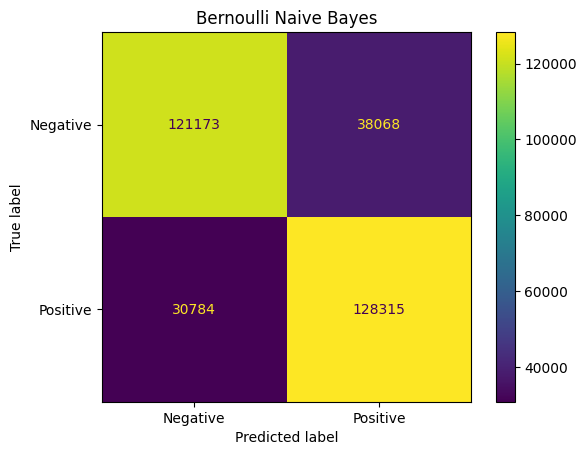

Linear SVM
Accuracy: 0.7945

Classification report:
              precision    recall  f1-score   support

    Negative     0.8042    0.7787    0.7912    159241
    Positive     0.7853    0.8103    0.7976    159099

    accuracy                         0.7945    318340
   macro avg     0.7947    0.7945    0.7944    318340
weighted avg     0.7948    0.7945    0.7944    318340



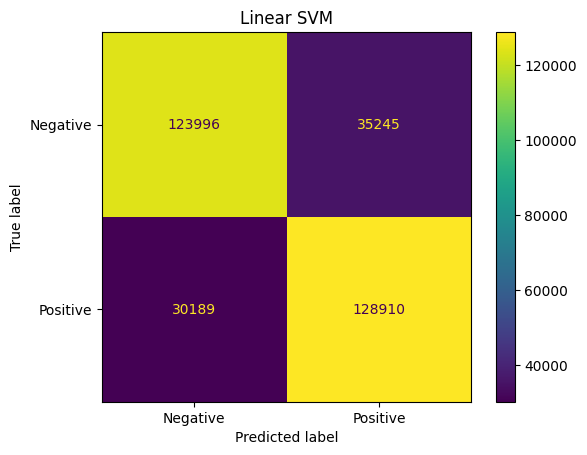

Logistic Regression
Accuracy: 0.8016

Classification report:
              precision    recall  f1-score   support

    Negative     0.8105    0.7875    0.7988    159241
    Positive     0.7932    0.8158    0.8043    159099

    accuracy                         0.8016    318340
   macro avg     0.8018    0.8016    0.8016    318340
weighted avg     0.8019    0.8016    0.8016    318340



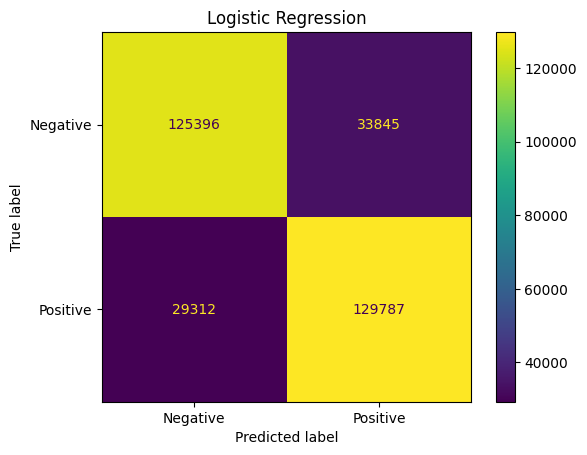

In [24]:
for model_name, y_pred in predictions.items():
    print("=" * 70)
    print(model_name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        digits=4,
    ))

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["Negative", "Positive"],
    ).plot(values_format="d")
    plt.title(model_name)
    plt.show()

## 11. Predict sentiment for custom local input

In [25]:
def predict_sentiment(tweets, model_name="Linear SVM"):
    """Preprocess and classify one tweet or a list of tweets."""
    if isinstance(tweets, str):
        tweets = [tweets]

    if model_name not in models:
        raise ValueError(
            f"Unknown model: {model_name}. Choose from {list(models.keys())}"
        )

    cleaned_tweets = [preprocess_text(tweet) for tweet in tweets]
    tweet_vectors = vectorizer.transform(cleaned_tweets)
    predicted_labels = models[model_name].predict(tweet_vectors)

    label_map = {0: "Negative", 1: "Positive"}

    return pd.DataFrame({
        "Tweet": tweets,
        "Processed Tweet": cleaned_tweets,
        "Predicted Sentiment": [label_map[label] for label in predicted_labels]
    })


sample_tweets = [
    "I absolutely love this product!",
    "This was the worst service I have ever received.",
    "The update is not bad at all.",
    "I waited all day and nobody helped me."
]

predict_sentiment(sample_tweets, model_name="Linear SVM")

,Tweet,Processed Tweet,Predicted Sentiment
0,I absolutely love this product!,absolutely love product,Positive
1,This was the worst service I have ever received.,worst service ever received,Negative
2,The update is not bad at all.,update not bad,Positive
3,I waited all day and nobody helped me.,waited day nobody helped,Negative


## 12. Save the trained model, vectorizer, and metadata locally

In [28]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

vectorizer_path = OUTPUT_DIR / "tfidf_vectorizer.joblib"
model_path = OUTPUT_DIR / "twitter_sentiment_model.joblib"
metadata_path = OUTPUT_DIR / "model_metadata.joblib"
results_path = OUTPUT_DIR / "model_results.csv"

joblib.dump(vectorizer, vectorizer_path)
joblib.dump(best_model, model_path)
joblib.dump({
    "best_model_name": best_model_name,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "max_tfidf_features": MAX_TFIDF_FEATURES,
    "training_rows": len(X_train),
    "testing_rows": len(X_test),
}, metadata_path)
results_df.to_csv(results_path, index=False)

print("Best model:", best_model_name)
print("Saved vectorizer:", vectorizer_path.resolve())
print("Saved model:", model_path.resolve())
print("Saved metadata:", metadata_path.resolve())
print("Saved results:", results_path.resolve())

Best model: Logistic Regression
Saved vectorizer: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\sentiment_model_outputs\tfidf_vectorizer.joblib
Saved model: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\sentiment_model_outputs\twitter_sentiment_model.joblib
Saved metadata: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\sentiment_model_outputs\model_metadata.joblib
Saved results: C:\Users\Adity\OneDrive\Desktop\ML\Projects\Twitter Sentiment Analyser\sentiment_model_outputs\model_results.csv


## 13. Reload the saved model in a new local session

Use this section later without retraining the model. The preprocessing functions and NLTK resources must still be available.

In [29]:
loaded_vectorizer = joblib.load(OUTPUT_DIR / "tfidf_vectorizer.joblib")
loaded_model = joblib.load(OUTPUT_DIR / "twitter_sentiment_model.joblib")
loaded_metadata = joblib.load(OUTPUT_DIR / "model_metadata.joblib")

def predict_with_saved_model(tweets):
    if isinstance(tweets, str):
        tweets = [tweets]

    cleaned = [preprocess_text(tweet) for tweet in tweets]
    vectors = loaded_vectorizer.transform(cleaned)
    labels = loaded_model.predict(vectors)
    label_map = {0: "Negative", 1: "Positive"}

    return pd.DataFrame({
        "Tweet": tweets,
        "Processed Tweet": cleaned,
        "Predicted Sentiment": [label_map[int(label)] for label in labels],
    })

print("Loaded model metadata:", loaded_metadata)
predict_with_saved_model([
    "I really enjoyed using this product.",
    "The experience was disappointing and frustrating.",
])

Loaded model metadata: {'best_model_name': 'Logistic Regression', 'random_state': 42, 'test_size': 0.2, 'max_tfidf_features': 100000, 'training_rows': 1273357, 'testing_rows': 318340}


,Tweet,Processed Tweet,Predicted Sentiment
0,I really enjoyed using this product.,really enjoyed using product,Positive
1,The experience was disappointing and frustrating.,experience disappointing frustrating,Negative
